In [1]:
import numpy as np
import pandas as pd
import os
import multiprocessing as mp
import warnings
warnings.filterwarnings("ignore")
from functools import partial
from scipy.optimize import curve_fit
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d, make_interp_spline
import matplotlib as mpl
import datetime
from dateutil.relativedelta import relativedelta
import scipy
import itertools

In [2]:
bs = np.array([0.05, 0.25, 0.5, 0.75, 1.0, 1.25, 1.50, 1.75])
exts = np.arange(2, 8.5, 0.5)
xx, yy = np.meshgrid(bs, exts, indexing='ij')

In [3]:
states_dir_1 = f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/grid_weighted_1e29_decay/states/3/'
states_dir_2 = f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/grid_weighted_1e29_decay_2/states/3/'

freqs = os.listdir(states_dir_1)
freqs

['7100',
 '7200',
 '7300',
 '7400',
 '7500',
 '7600',
 '7700',
 '7800',
 '7900',
 '8000']

In [17]:
yy

array([[2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ],
       [2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]])

In [12]:
snrs_1 = np.load(os.path.join(states_dir_1, freqs[0], 'snrs.npy'))
snrs_2 = np.load(os.path.join(states_dir_2, freqs[0], 'snrs.npy'))
np.concatenate([snrs_1, snrs_2], axis=1)

array([[1.09861199, 1.34517653, 1.36944207, 1.27011582, 1.04062171,
        0.77520947, 0.89793686, 0.89793686, 1.00912872, 1.18583316,
        1.31799163, 1.82981356, 2.03376718, 2.17629147],
       [1.22541817, 1.30066927, 1.26750566, 1.10263166, 0.84289875,
        0.71122483, 0.81064674, 0.81064674, 0.90694325, 1.06805725,
        1.29227247, 1.69494022, 1.92893224, 1.98386981],
       [1.25575453, 1.28314133, 1.25601244, 1.05669852, 0.78117047,
        0.74143595, 0.84398633, 0.84398633, 0.94588192, 1.10762355,
        1.3383799 , 1.76126769, 1.97009239, 2.00272629],
       [1.27299525, 1.29214052, 1.24996027, 1.03150599, 0.74805656,
        0.76841043, 0.87028491, 0.87028491, 0.97803472, 1.13880742,
        1.37463886, 1.81757823, 1.99682977, 2.01145069],
       [1.2843177 , 1.30351972, 1.24650339, 1.01386908, 0.72508095,
        0.79021115, 0.88982246, 0.88982246, 1.00085479, 1.16185549,
        1.40465059, 1.86444085, 2.01569025, 2.01591261],
       [1.29223598, 1.32018378, 1.2

In [15]:
np.concatenate([snrs_1, snrs_2], axis=1).shape

(8, 14)

In [20]:
snrs_1[:, :-1]

array([[1.09861199, 1.34517653, 1.36944207, 1.27011582, 1.04062171,
        0.77520947],
       [1.22541817, 1.30066927, 1.26750566, 1.10263166, 0.84289875,
        0.71122483],
       [1.25575453, 1.28314133, 1.25601244, 1.05669852, 0.78117047,
        0.74143595],
       [1.27299525, 1.29214052, 1.24996027, 1.03150599, 0.74805656,
        0.76841043],
       [1.2843177 , 1.30351972, 1.24650339, 1.01386908, 0.72508095,
        0.79021115],
       [1.29223598, 1.32018378, 1.24447074, 1.00040931, 0.70809347,
        0.8079617 ],
       [1.2980552 , 1.33570499, 1.24326213, 0.98974751, 0.69447737,
        0.82219197],
       [1.30250228, 1.34788722, 1.24254629, 0.98111423, 0.68328254,
        0.83379515]])

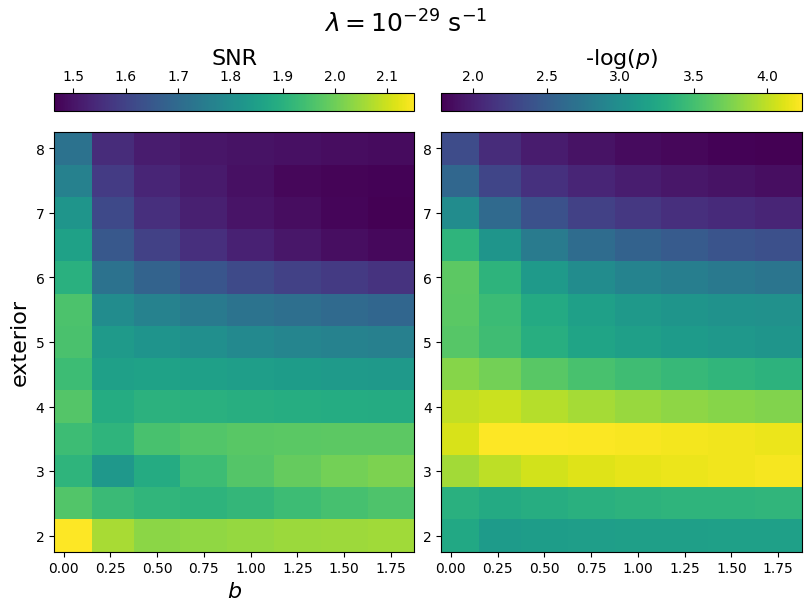

In [26]:
fig, axs = plt.subplots(1, 2, layout='constrained', figsize=(8, 6))
tails = ['snrs.npy', 'pvals.npy']
labels = ['SNR', r'-$\log(p)$']

for ax, tail, label in zip(axs, tails, labels):
    grid = np.array([
        np.concatenate(
            [
                np.load(os.path.join(states_dir_1, freq, tail))[:, :-1], #remove exterior=5
                np.load(os.path.join(states_dir_2, freq, tail))
            ],
            axis=1
        )
        for freq in freqs
    ])
    sum_grid = np.mean(grid, axis=0)
    pcm = ax.pcolormesh(xx, yy, sum_grid, cmap='viridis')
    cbar = fig.colorbar(pcm, ax=ax, location='top')
    cbar.set_label(label, fontsize=16)
    if label == 'SNR':
        ax.set_xlabel('$b$', fontsize=16)
        ax.set_ylabel('exterior', fontsize=16)

fig.suptitle(r'$\lambda = 10^{-29}$ $\mathrm{s}^{-1}$', fontsize=18)
fig.savefig(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/bank_3_1e29_results.png', dpi=300, bbox_inches='tight')

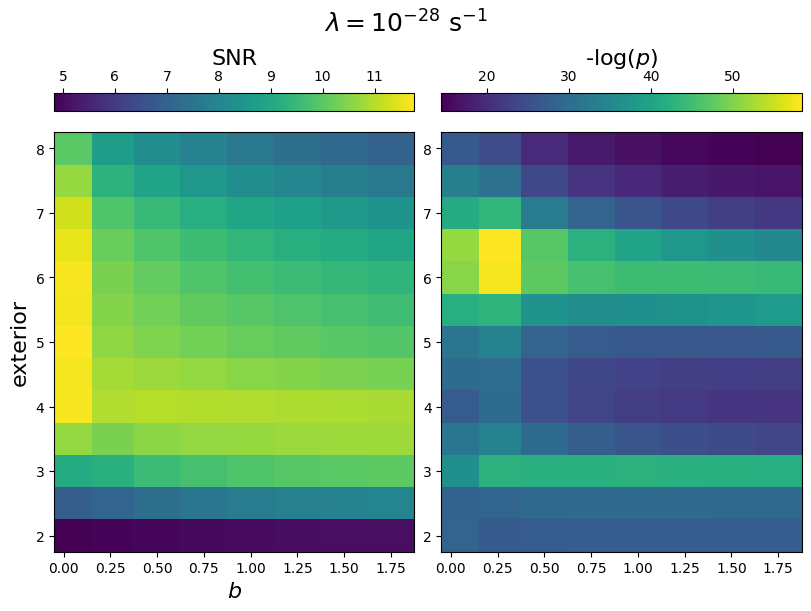

In [27]:
states_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/grid_weighted_1e28_decay_bank_3/states/3/'
fig, axs = plt.subplots(1, 2, layout='constrained', figsize=(8, 6))
tails = ['snrs.npy', 'pvals.npy']
labels = ['SNR', r'-$\log(p)$']

for ax, tail, label in zip(axs, tails, labels):
    grid = np.array([
        np.load(os.path.join(states_dir, freq, tail))
        for freq in freqs
    ])
    sum_grid = np.mean(grid, axis=0)
    pcm = ax.pcolormesh(xx, yy, sum_grid, cmap='viridis')
    cbar = fig.colorbar(pcm, ax=ax, location='top')
    cbar.set_label(label, fontsize=16)
    if label == 'SNR':
        ax.set_xlabel('$b$', fontsize=16)
        ax.set_ylabel('exterior', fontsize=16)

fig.suptitle(r'$\lambda = 10^{-28}$ $\mathrm{s}^{-1}$', fontsize=18)
fig.savefig(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/bank_3_1e28_results.png', dpi=300, bbox_inches='tight')

# 5500 MHz - comparing p-values and limits

In [3]:
bs = np.array([0.05, 0.25, 0.5, 0.75, 1.0, 1.25, 1.50, 1.75])
exts = np.arange(2, 8.5, 0.5)
xx, yy = np.meshgrid(bs, exts, indexing='ij')

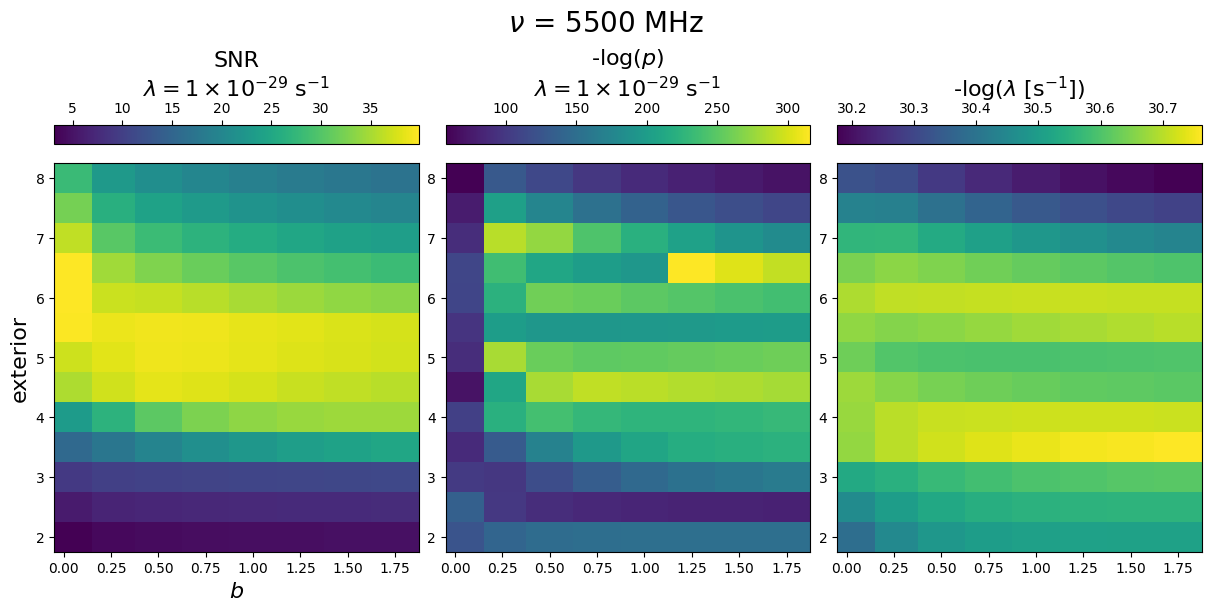

In [7]:
states_dir_1 = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/grid_weighted_1e29_decay/states/1/5500'
states_dir_2 = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/grid_weighted_1e29_decay_2/states/1/5500'
limits_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/snr_evals_cband/mini_analysis_5500_weighted_decay/states'

fig, axs = plt.subplots(1, 3, layout='constrained', figsize=(12, 6))
tails = ['snrs.npy', 'pvals.npy', 'results.npy']
labels = [
    'SNR\n$\\lambda = 1 \\times 10^{-29}$ $\\mathrm{s}^{-1}$',
    '-$\\log(p)$\n$\\lambda = 1 \\times 10^{-29}$ $\\mathrm{s}^{-1}$',
    '-log($\\lambda$ [s$^{-1}$])'
]

for ax, tail, label in zip(axs, tails, labels):
    if tail == 'results.npy':
        grid = np.load(os.path.join(limits_dir, tail))
    else:
        grid = np.concatenate(
            [
                np.load(os.path.join(states_dir_1, tail))[:, :-1], #remove exterior=5
                np.load(os.path.join(states_dir_2, tail))
            ],
            axis=1
        )
    pcm = ax.pcolormesh(xx, yy, grid, cmap='viridis')
    cbar = fig.colorbar(pcm, ax=ax, location='top')
    cbar.set_label(label, fontsize=16)
    if tail == 'snrs.npy':
        ax.set_xlabel('$b$', fontsize=16)
        ax.set_ylabel('exterior', fontsize=16)

fig.suptitle(r'$\nu$ = 5500 MHz', fontsize=20)
fig.savefig(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/mini_analysis_5500_comparison.png', dpi=300, bbox_inches='tight')